In [1]:
import os
import gc
import time
import sys
print(sys.executable)
import numpy as np
import matplotlib.pyplot as plt
import h5py
import pyfftw
from pyfftw.interfaces.numpy_fft import rfft2, irfft2
from scipy.fft import fftfreq, rfftfreq 
try:
    import cupy as cp
    GPU_AVAILABLE = True
    mempool = cp.get_default_memory_pool()
    print(f"GPU: {cp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")
except ImportError:
    GPU_AVAILABLE = False
    print("CuPy not found CPU only")

pyfftw.interfaces.cache.enable()

/home/ahmaide/miniconda3/envs/cwt/bin/python
GPU: NVIDIA RTX 6000 Ada Generation


In [2]:
def bytes_human(n):
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if n < 1024:
            return f"{n:.1f} {unit}"
        n /= 1024.0

def show_cwt_map(coeff, title=None, pclip=(1, 99)):
    if GPU_AVAILABLE and isinstance(coeff, cp.ndarray):
        coeff = cp.asnumpy(coeff)
    mag = np.abs(coeff).astype(np.float32)
    viz = np.log1p(mag)
    vmin, vmax = np.percentile(viz, pclip)
    plt.figure(figsize=(12, 6))
    plt.imshow(viz, origin="lower", aspect="auto", vmin=vmin, vmax=vmax)
    plt.colorbar(label="log(1+|coeff|)")
    if title:
        plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.show()

def cwt2_gpu(X_np, sigmas, keep_last=False):
    H, W = X_np.shape
    timings = []
    last_coeff = None

    # Transfer to GPU only if not already there
    if isinstance(X_np, cp.ndarray):
        X_gpu = X_np
        timings.append(("CPU→GPU transfer", 0.0))
    else:
        t0 = time.perf_counter()
        X_gpu = cp.asarray(X_np, dtype=cp.float32)
        cp.cuda.Stream.null.synchronize()
        timings.append(("CPU→GPU transfer", time.perf_counter() - t0))

    # Forward FFT
    t0 = time.perf_counter()
    F = cp.fft.rfft2(X_gpu)
    cp.cuda.Stream.null.synchronize()
    timings.append(("rfft2_forward", time.perf_counter() - t0))

    del X_gpu
    mempool.free_all_blocks()

    ky = (2 * cp.pi) * cp.fft.fftfreq(H).astype(cp.float32)
    kx = (2 * cp.pi) * cp.fft.rfftfreq(W).astype(cp.float32)
    k2 = ky[:, None] ** 2 + kx[None, :] ** 2

    psi_hat = cp.empty_like(k2)
    Ff = cp.empty_like(F)

    for s in sigmas:
        s = float(s)
        t1 = time.perf_counter()

        cp.multiply(-0.5 * s * s, k2, out=psi_hat)
        cp.exp(psi_hat, out=psi_hat)
        cp.multiply(k2, psi_hat, out=psi_hat)
        cp.multiply(F, psi_hat, out=Ff)

        coeff = cp.fft.irfft2(Ff, s=(H, W))
        cp.cuda.Stream.null.synchronize()

        dt = time.perf_counter() - t1
        timings.append((f"scale_{s}", dt))

        if keep_last:
            last_coeff = coeff
        else:
            del coeff
        mempool.free_all_blocks()

    del F, k2, psi_hat, Ff
    mempool.free_all_blocks()
    return timings, last_coeff


def cwt2_cpu(X, sigmas, keep_last=False):
    from scipy.fft import rfft2, irfft2, fftfreq, rfftfreq

    H, W = X.shape
    X = np.ascontiguousarray(X, dtype=np.float32)
    timings = []
    last_coeff = None
    workers = os.cpu_count() or 1

    t0 = time.perf_counter()
    F = rfft2(X, workers=workers)
    timings.append(("rfft2_forward", time.perf_counter() - t0))

    ky = (2 * np.pi) * fftfreq(H, d=1.0).astype(np.float32)
    kx = (2 * np.pi) * rfftfreq(W, d=1.0).astype(np.float32)
    k2 = ky[:, None] ** 2 + kx[None, :] ** 2

    psi_hat = np.empty_like(k2)
    Ff = np.empty_like(F)

    for s in sigmas:
        s = float(s)
        t1 = time.perf_counter()

        np.multiply(-0.5 * s * s, k2, out=psi_hat)
        np.exp(psi_hat, out=psi_hat)
        np.multiply(k2, psi_hat, out=psi_hat)
        np.multiply(F, psi_hat, out=Ff)

        coeff = irfft2(Ff, s=(H, W), workers=workers)
        dt = time.perf_counter() - t1
        timings.append((f"scale_{s}", dt))

        if keep_last:
            last_coeff = coeff.astype(np.float32, copy=False)
        else:
            del coeff
        gc.collect()

    return timings, last_coeff

import cupyx.scipy.ndimage as cpndimage
def cwt2_gpu_subsampled(X_np, sigmas, keep_last=False, ds_rows=None, ds_cols=None):
    H, W = X_np.shape
    timings = []
    last_coeff = None
    # Transfer to GPU
    t0 = time.perf_counter()
    X_gpu = cp.asarray(X_np, dtype=cp.float32)
    cp.cuda.Stream.null.synchronize()
    timings.append(("CPU→GPU transfer", time.perf_counter() - t0))
    for s in sigmas:
        s = float(s)
        # Separate factor for each dimension
        ds_r = ds_rows if ds_rows is not None else max(1, int(s // 2))
        ds_c = ds_cols if ds_cols is not None else max(1, int(s // 2))
        scale_r = 1.0 / ds_r
        scale_c = 1.0 / ds_c
        # Separate sigma for each dimension
        sigma_r = s / ds_r
        sigma_c = s / ds_c
        # Downsample on GPU
        t0 = time.perf_counter()
        X_small = cpndimage.zoom(X_gpu, (scale_r, scale_c), order=1)
        cp.cuda.Stream.null.synchronize()
        t_down = time.perf_counter() - t0
        timings.append(("downsample", t_down))
        Hs, Ws = X_small.shape
        print(f"  Original:      {H} × {W} = {H*W:,} values")
        print(f"  Downsampled:   {Hs} × {Ws} = {Hs*Ws:,} values")
        print(f"  Row factor:    {ds_r}×")
        print(f"  Column factor: {ds_c}×")
        print(f"  Total reduction: {(H*W)/(Hs*Ws):.0f}×")
        t0 = time.perf_counter()
        F = cp.fft.rfft2(X_small)
        cp.cuda.Stream.null.synchronize()
        t_fft = time.perf_counter() - t0
        timings.append(("rfft2_forward (small)", t_fft))
        del X_small
        mempool.free_all_blocks()
        ky = (2 * cp.pi) * cp.fft.fftfreq(Hs).astype(cp.float32)
        kx = (2 * cp.pi) * cp.fft.rfftfreq(Ws).astype(cp.float32)
        t0 = time.perf_counter()
        ky_scaled = ky * sigma_r
        kx_scaled = kx * sigma_c
        k2 = ky_scaled[:, None] ** 2 + kx_scaled[None, :] ** 2
        psi_hat = (ky[:, None] ** 2 + kx[None, :] ** 2) * cp.exp(-0.5 * k2)
        Ff = F * psi_hat
        coeff_small = cp.fft.irfft2(Ff, s=(Hs, Ws))
        cp.cuda.Stream.null.synchronize()
        t_kernel = time.perf_counter() - t0
        timings.append(("LoG kernel + ifft (small)", t_kernel))
        del F, k2, psi_hat, Ff, ky_scaled, kx_scaled
        mempool.free_all_blocks()
        # Upsample back
        t0 = time.perf_counter()
        coeff = cpndimage.zoom(coeff_small, (ds_r, ds_c), order=3)
        coeff = coeff[:H, :W]
        cp.cuda.Stream.null.synchronize()
        t_up = time.perf_counter() - t0
        timings.append(("upsample", t_up))
        del coeff_small
        mempool.free_all_blocks()
        if keep_last:
            last_coeff = coeff
        else:
            del coeff
        mempool.free_all_blocks()
    del X_gpu
    mempool.free_all_blocks()
    return timings, last_coeff


def cwt2_log_pyfftw(X, sigmas, threads=None, keep_last=False):
    H, W = X.shape
    X = np.ascontiguousarray(X, dtype=np.float32)

    if threads is None:
        threads = os.cpu_count() or 1

    timings = []
    last_coeff = None

    t0 = time.perf_counter()
    F = rfft2(X, threads=threads)
    t_fft = time.perf_counter() - t0
    timings.append(("rfft2_forward", t_fft))

    ky = (2 * np.pi) * fftfreq(H, d=1.0).astype(np.float32)
    kx = (2 * np.pi) * rfftfreq(W, d=1.0).astype(np.float32)   
    k2 = ky[:, None]**2 + kx[None, :]**2                  

    psi_hat = np.empty_like(k2, dtype=np.float32)
    Ff = np.empty_like(F, dtype=np.complex64)

    for s in sigmas:
        s = float(s)
        t1 = time.perf_counter()

        np.multiply(-0.5 * s * s, k2, out=psi_hat)
        np.exp(psi_hat, out=psi_hat)
        np.multiply(k2, psi_hat, out=psi_hat)

        np.multiply(F, psi_hat.astype(F.dtype, copy=False), out=Ff)

        coeff = irfft2(Ff, s=(H, W), threads=threads).astype(np.float32, copy=False)

        dt = time.perf_counter() - t1
        timings.append((f"scale_{s}", dt))

        if keep_last:
            last_coeff = coeff
        else:
            del coeff
        gc.collect()

    return timings, last_coeff

In [2]:
import h5py

with h5py.File("DF__UTC_20201112_000132.602.h5", "r") as f:
    print("Keys:", list(f.keys()))
    
    # Print all datasets and their shapes
    def print_structure(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"  {name}: shape={obj.shape}, dtype={obj.dtype}")
    
    f.visititems(print_structure)

Keys: ['Acoustic']
  Acoustic: shape=(30000, 6912), dtype=int16


In [8]:
with h5py.File("DF__UTC_20201112_000132.602.h5", "r") as f:
    arr = f["Acoustic"][()]
    print(f"Raw shape: {arr.shape}")

X = np.ascontiguousarray(arr.T, dtype=np.float32)
print(f"Prepared shape: {X.shape}")
print(f"Memory: {bytes_human(X.nbytes)}")
del arr
gc.collect()

Raw shape: (30000, 6912)
Prepared shape: (6912, 30000)
Memory: 791.0 MB


0

GPU BENCHMARK
      CPU→GPU transfer: 3.1461 s
         rfft2_forward: 0.0604 s
            scale_32.0: 0.0327 s
                 TOTAL: 3.3201 s


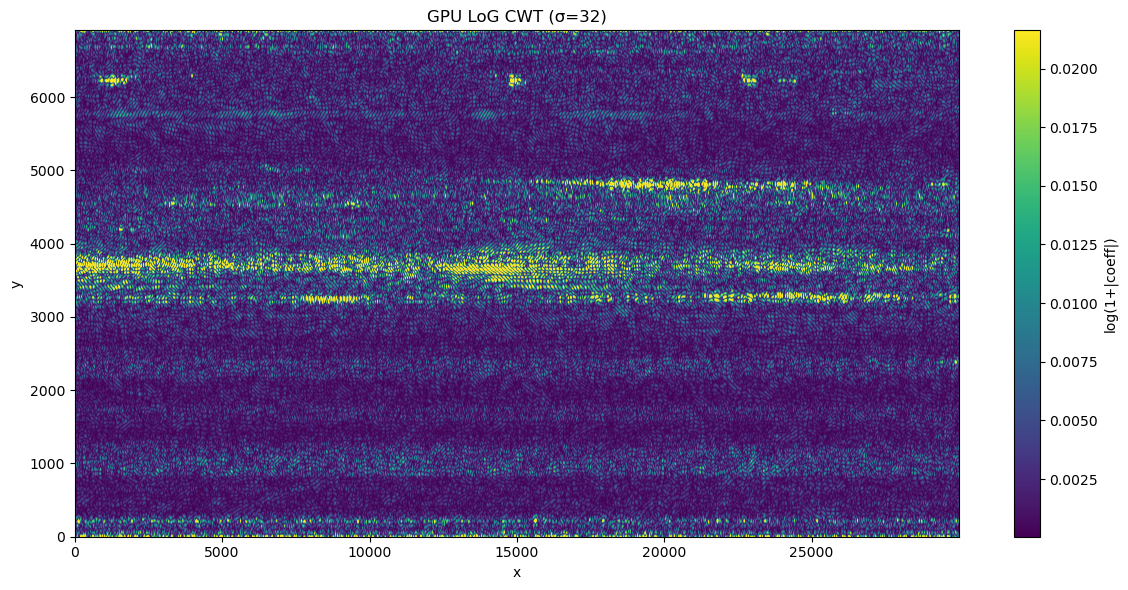

In [9]:
scales = [32]

print("GPU BENCHMARK")
t1 = time.perf_counter()
timings, coeff_gpu = cwt2_gpu(X, scales, keep_last=True)
t_total = time.perf_counter() - t1

for label, dt in timings:
    print(f"  {label:>20}: {dt:.4f} s")
print(f"  {'TOTAL':>20}: {t_total:.4f} s")

show_cwt_map(coeff_gpu, title=f"GPU LoG CWT (σ=32)")

CPU BENCHMARK
         rfft2_forward: 0.0381 s
            scale_32.0: 0.1967 s
                 TOTAL: 0.2849 s


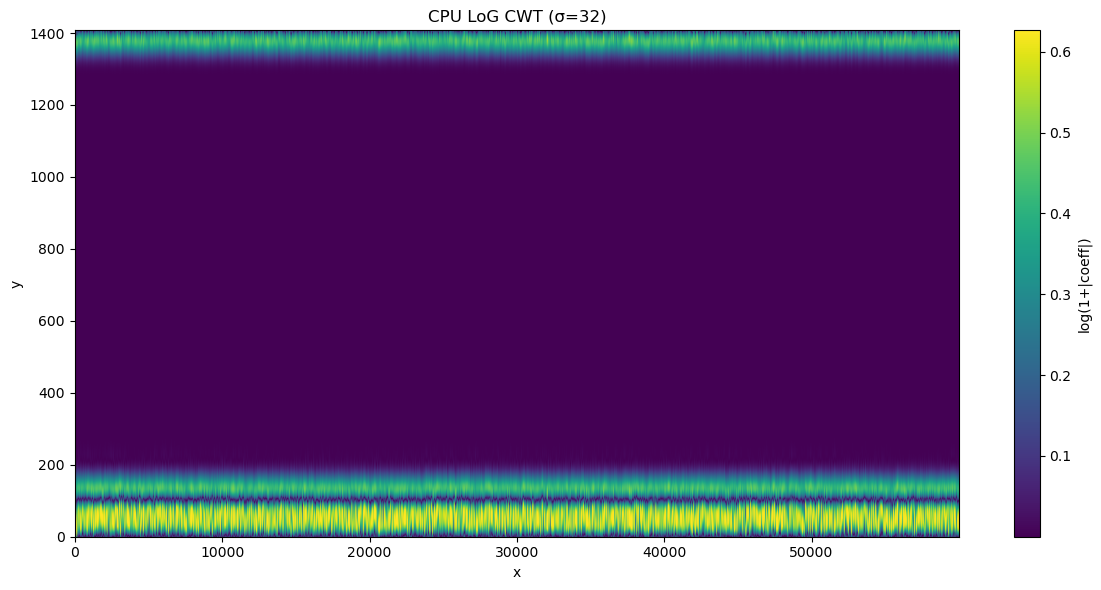

In [4]:
scales = [32]
print("CPU BENCHMARK")
t1 = time.perf_counter()
timings, coeff_cpu = cwt2_cpu(X, scales, keep_last=True)
t_total = time.perf_counter() - t1

for label, dt in timings:
    print(f"  {label:>20}: {dt:.4f} s")
print(f"  {'TOTAL':>20}: {t_total:.4f} s")

show_cwt_map(coeff_cpu, title=f"CPU LoG CWT (σ=32)")

GPU + SUBSAMPLING BENCHMARK
  Original:      6912 × 30000 = 207,360,000 values
  Downsampled:   3456 × 1875 = 6,480,000 values
  Row factor:    2×
  Column factor: 16×
  Total reduction: 32×
                CPU→GPU transfer: 0.4536 s
                      downsample: 0.3225 s
           rfft2_forward (small): 0.1753 s
       LoG kernel + ifft (small): 0.0232 s
                        upsample: 0.3193 s
                           TOTAL: 1.3460 s


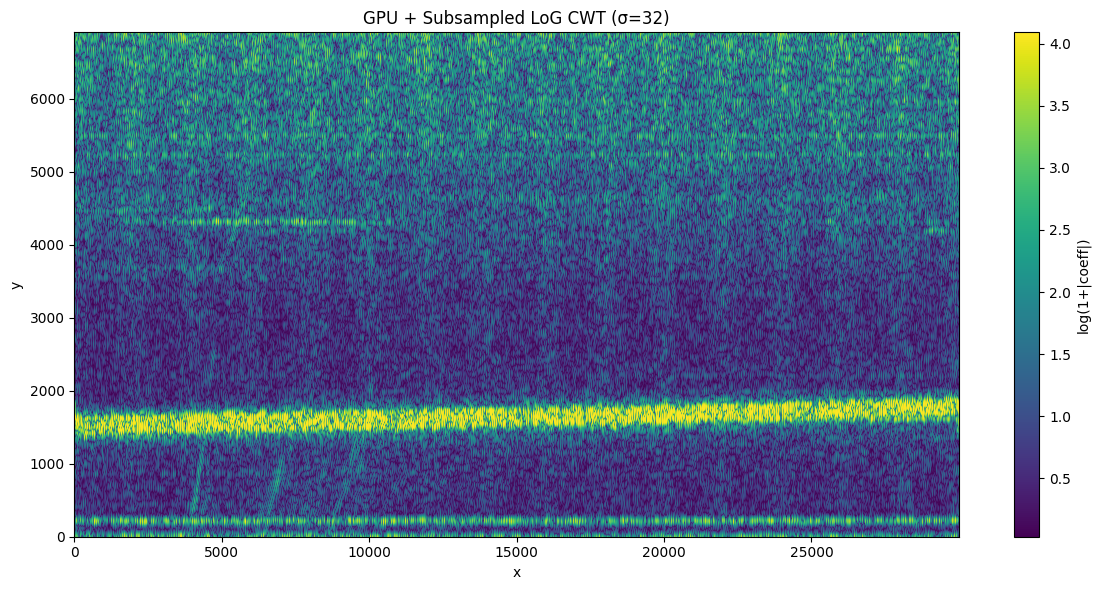

In [ ]:
scales = [32]
print("=" * 60)
print("GPU + SUBSAMPLING BENCHMARK")
print("=" * 60)
t1 = time.perf_counter()
timings, coeff_sub = cwt2_gpu_subsampled(X, scales, keep_last=True, ds_rows=2)
t_total = time.perf_counter() - t1

for label, dt in timings:
    print(f"  {label:>30}: {dt:.4f} s")
print(f"  {'TOTAL':>30}: {t_total:.4f} s")
show_cwt_map(coeff_sub, title="GPU + Subsampled LoG CWT (σ=32)")

PyFFTW CPU BENCHMARK
  Using 20 threads
         rfft2_forward: 1.2018 s
            scale_32.0: 3.1695 s
                 TOTAL: 4.9333 s


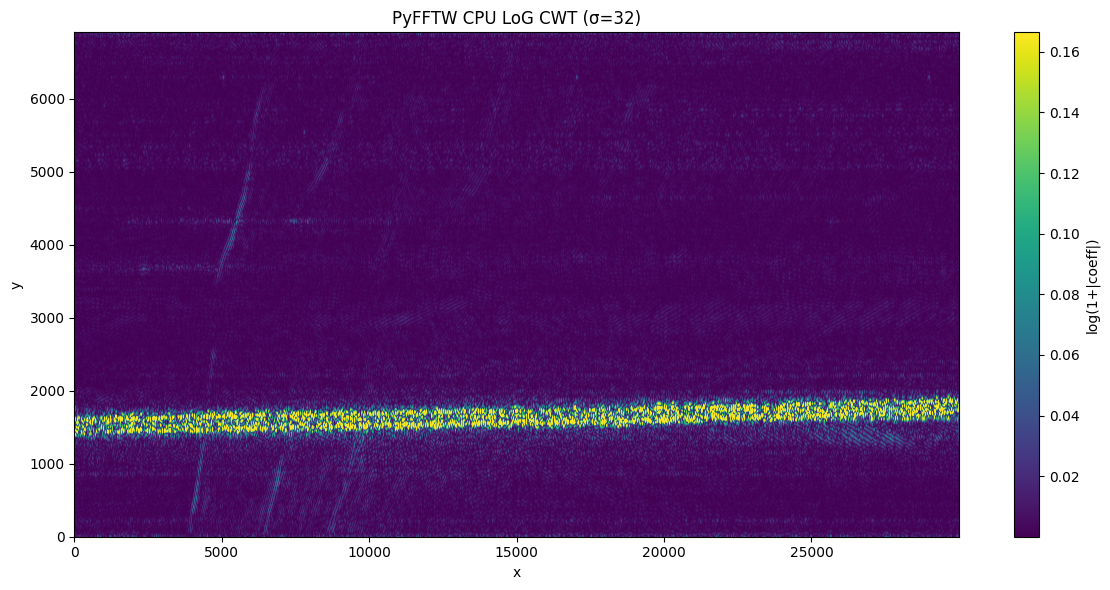

In [4]:
scales = [32]

print("=" * 60)
print("PyFFTW CPU BENCHMARK")
print("=" * 60)
print(f"  Using {os.cpu_count()} threads")

t1 = time.perf_counter()
timings, coeff_pyfftw = cwt2_log_pyfftw(X, scales, keep_last=True)
t_total = time.perf_counter() - t1

for label, dt in timings:
    print(f"  {label:>20}: {dt:.4f} s")
print(f"  {'TOTAL':>20}: {t_total:.4f} s")

show_cwt_map(coeff_pyfftw, title="PyFFTW CPU LoG CWT (σ=32)")

In [6]:
files = [
    {
        "path": "BM73-22_UTC_20230203_081837.149.h5",                          
        "dataset": "Acquisition/Raw[0]/RawData",     
    },
    {
        "path": "BM73-22_UTC_20230203_052637.149.h5",                          
        "dataset": "Acquisition/Raw[0]/RawData",     
    },
    {
        "path": "BM73-22_UTC_20230203_052437.149.h5",                          
        "dataset": "Acquisition/Raw[0]/RawData",     
    },
]

scales = [32]

In [3]:
all_timings = {}
all_coeffs = {}

total_start = time.perf_counter()

for i, file_info in enumerate(files):
    filepath = file_info["path"]
    dataset_key = file_info["dataset"]
    
    print("=" * 60)
    print(f"FILE {i+1}: {filepath}")
    print("=" * 60)

    #Load
    t0 = time.perf_counter()
    with h5py.File(filepath, "r") as f:
        arr = f[dataset_key][()]
    t_load = time.perf_counter() - t0
    print(f"  Raw shape:       {arr.shape}")
    print(f"  Load time:       {t_load:.4f} s")

    #Prepare
    t0 = time.perf_counter()
    X = np.ascontiguousarray(arr.T, dtype=np.float32)
    t_prep = time.perf_counter() - t0
    print(f"  Prepared shape:  {X.shape}")
    print(f"  Memory:          {bytes_human(X.nbytes)}")
    print(f"  Prep time:       {t_prep:.4f} s")
    del arr

    #GPU CWT
    print(f"\n  GPU Processing (σ={scales}):")
    t0 = time.perf_counter()
    timings, coeff = cwt2_gpu(X, scales, keep_last=True)
    t_gpu = time.perf_counter() - t0

    for label, dt in timings:
        print(f"    {label:>20}: {dt:.4f} s")
    print(f"    {'GPU TOTAL':>20}: {t_gpu:.4f} s")

    #Results
    file_total = t_load + t_prep + t_gpu
    all_timings[filepath] = {
        "load": t_load,
        "prep": t_prep,
        "gpu_steps": timings,
        "gpu_total": t_gpu,
        "file_total": file_total,
    }
    all_coeffs[filepath] = coeff

    print(f"\n  FILE TOTAL:      {file_total:.4f} s")
    del X
    gc.collect()

total_end = time.perf_counter()
total_time = total_end - total_start
print("=" * 60)
print(f"ALL FILES TOTAL:   {total_time:.4f} s")
print("=" * 60)

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"{'File':<40} {'Load':>8} {'Prep':>8} {'GPU':>8} {'Total':>8}")
print("-" * 72)

for filepath, t in all_timings.items():
    name = filepath.split("/")[-1].split("\\")[-1]
    print(f"{name:<40} {t['load']:>8.4f} {t['prep']:>8.4f} {t['gpu_total']:>8.4f} {t['file_total']:>8.4f}")

print("-" * 72)
print(f"{'TOTAL':<40} {'':<8} {'':<8} {'':<8} {total_time:>8.4f}")

print("Plotting results....................................................")

for filepath, coeff in all_coeffs.items():
    name = filepath.split("/")[-1].split("\\")[-1]
    t = all_timings[filepath]["file_total"]
    show_cwt_map(coeff, title=f"{name} — GPU LoG CWT (σ=32) — {t:.2f}s total")

print("Cleaning Memory......................................................................")

del all_coeffs
gc.collect()
if GPU_AVAILABLE:
    mempool.free_all_blocks()
print("Memory cleared........................................................................")



NameError: name 'files' is not defined

LOADING AND STACKING ALL FILES
  File 1: BM73-22_UTC_20230203_081837.149.h5
    Shape: (1408, 60000)
    Load:  0.0377 s
    Prep:  0.1217 s
  File 2: BM73-22_UTC_20230203_052637.149.h5
    Shape: (1408, 60000)
    Load:  0.0352 s
    Prep:  0.1252 s
  File 3: BM73-22_UTC_20230203_052437.149.h5
    Shape: (1408, 60000)
    Load:  0.0393 s
    Prep:  0.1199 s

  Individual shapes: [(1408, 60000), (1408, 60000), (1408, 60000)]
  Stacked shape:     (1408, 180000)
  Stacked memory:    966.8 MB
  Stack time:        0.1102 s

  TOTAL LOAD+STACK:  0.6208 s

GPU PROCESSING (STACKED)
      CPU→GPU transfer: 0.0979 s
         rfft2_forward: 0.0155 s
            scale_32.0: 0.0285 s
             GPU TOTAL: 0.1594 s

  EVERYTHING TOTAL:  0.7802 s

STACKING SUMMARY

Per-file loading:
  File                                         Load     Prep    Total
----------------------------------------------------------------
  BM73-22_UTC_20230203_081837.149.h5         0.0377   0.1217   0.1594
  BM73-22_UTC

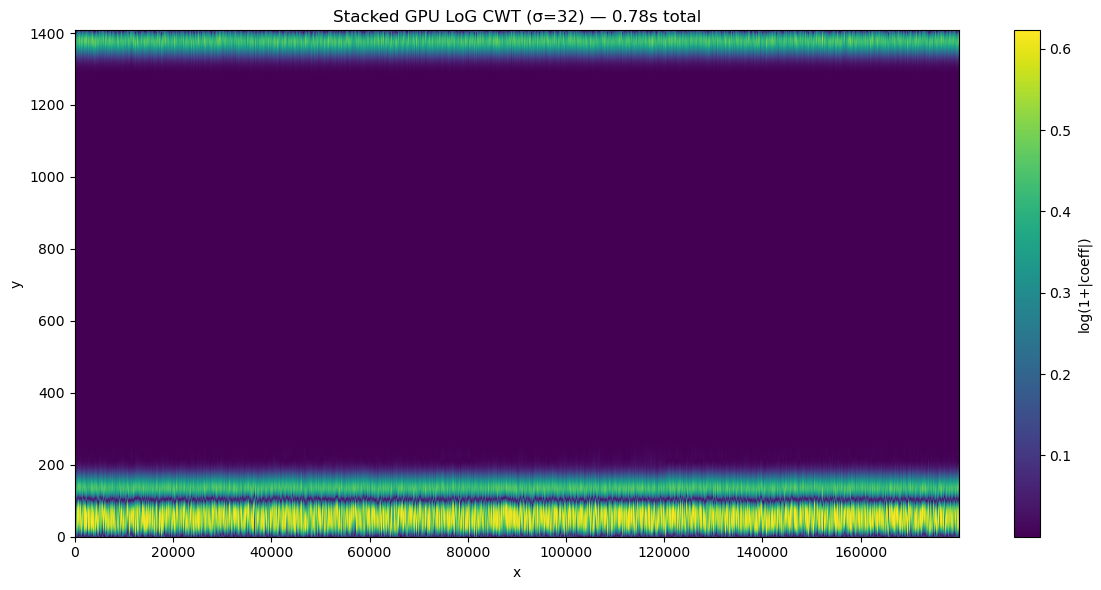

Cleaning .............................................................
Memory cleared


In [ ]:
all_arrays = []
load_times = []

print("=" * 60)
print("LOADING AND STACKING ALL FILES")
print("=" * 60)

total_start = time.perf_counter()

for i, file_info in enumerate(files):
    filepath = file_info["path"]
    dataset_key = file_info["dataset"]

    #Load
    t0 = time.perf_counter()
    with h5py.File(filepath, "r") as f:
        arr = f[dataset_key][()]
    t_load = time.perf_counter() - t0

    #Prepare
    t0 = time.perf_counter()
    X = np.ascontiguousarray(arr.T, dtype=np.float32)
    t_prep = time.perf_counter() - t0
    del arr

    total_file = t_load + t_prep
    load_times.append((filepath, t_load, t_prep, total_file))

    print(f"  File {i+1}: {filepath}")
    print(f"    Shape: {X.shape}")
    print(f"    Load:  {t_load:.4f} s")
    print(f"    Prep:  {t_prep:.4f} s")

    all_arrays.append(X)

#Stack into onearray
t0 = time.perf_counter()
stacked = np.concatenate(all_arrays, axis=1)  # Stack along time axis
t_stack = time.perf_counter() - t0

print(f"\n  Individual shapes: {[a.shape for a in all_arrays]}")
print(f"  Stacked shape:     {stacked.shape}")
print(f"  Stacked memory:    {bytes_human(stacked.nbytes)}")
print(f"  Stack time:        {t_stack:.4f} s")

del all_arrays
gc.collect()

t_all_load = time.perf_counter() - total_start
print(f"\n  TOTAL LOAD+STACK:  {t_all_load:.4f} s")

print("\n" + "=" * 60)
print("GPU PROCESSING (STACKED)")
print("=" * 60)

t0 = time.perf_counter()
timings, coeff_stacked = cwt2_gpu(stacked, scales, keep_last=True)
t_gpu = time.perf_counter() - t0

for label, dt in timings:
    print(f"  {label:>20}: {dt:.4f} s")
print(f"  {'GPU TOTAL':>20}: {t_gpu:.4f} s")

total_time = t_all_load + t_gpu
print(f"\n  EVERYTHING TOTAL:  {total_time:.4f} s")

del stacked
gc.collect()


print("\n" + "=" * 60)
print("STACKING SUMMARY")
print("=" * 60)

print("\nPer-file loading:")
print(f"  {'File':<40} {'Load':>8} {'Prep':>8} {'Total':>8}")
print("-" * 64)
for filepath, t_load, t_prep, t_total in load_times:
    name = filepath.split("/")[-1].split("\\")[-1]
    print(f"  {name:<40} {t_load:>8.4f} {t_prep:>8.4f} {t_total:>8.4f}")

print(f"\n  Stacking time:     {t_stack:.4f} s")
print(f"  Total load+stack:  {t_all_load:.4f} s")
print(f"  GPU processing:    {t_gpu:.4f} s")
print(f"  TOTAL:             {total_time:.4f} s")

print("Plotting .............................................................")

show_cwt_map(coeff_stacked, title=f"Stacked GPU LoG CWT (σ=32) — {total_time:.2f}s total")

print("Cleaning .............................................................")

del coeff_stacked
gc.collect()
if GPU_AVAILABLE:
    mempool.free_all_blocks()
print("Memory cleared")

LOADING AND STACKING ALL FILES (GPU)
  File 1: BM73-22_UTC_20230203_081837.149.h5
    Shape:    (1408, 60000)
    Load:     0.0373 s
    Transfer: 0.0752 s
    Prepare:  0.0030 s
  File 2: BM73-22_UTC_20230203_052637.149.h5
    Shape:    (1408, 60000)
    Load:     0.0351 s
    Transfer: 0.0581 s
    Prepare:  0.0025 s
  File 3: BM73-22_UTC_20230203_052437.149.h5
    Shape:    (1408, 60000)
    Load:     0.0363 s
    Transfer: 0.0578 s
    Prepare:  0.0026 s

  Stacked shape:  (1408, 180000)
  Stacked memory: 966.8 MB
  Stack time:     0.0033 s
  TOTAL LOAD+STACK: 0.3167 s

GPU PROCESSING (STACKED)
      CPU→GPU transfer: 0.0000 s
         rfft2_forward: 0.0179 s
            scale_32.0: 0.0281 s
             GPU TOTAL: 0.0562 s

  EVERYTHING TOTAL:  0.3729 s

STACKING SUMMARY (GPU)

File                                    Load     Xfer     Prep    Total
-------------------------------------------------------------------
BM73-22_UTC_20230203_081837.149.h5    0.0373   0.0752   0.0030   0

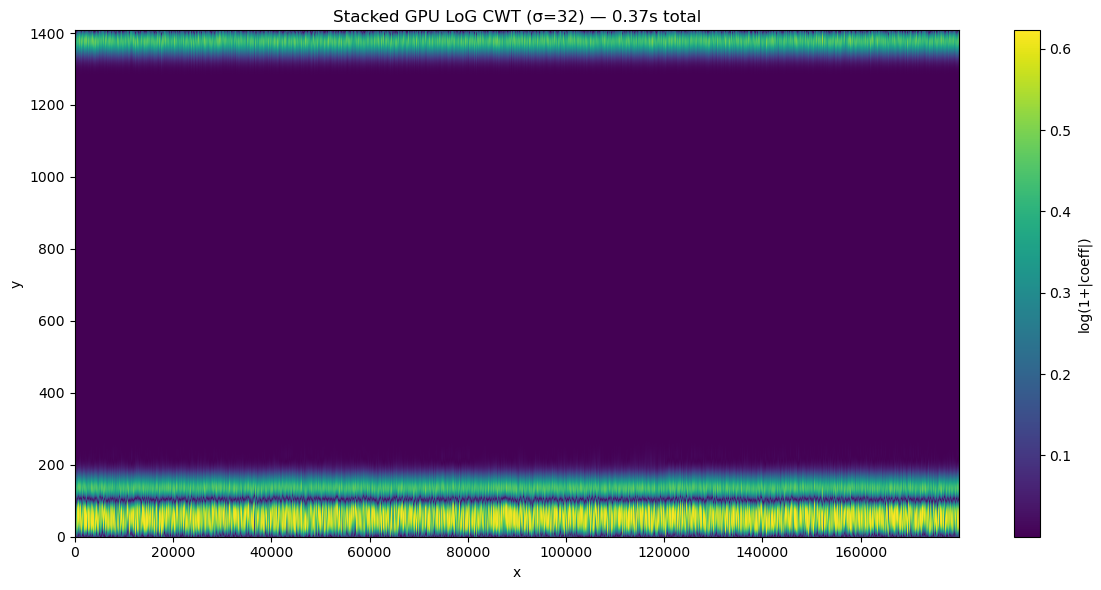


Cleaning .............................................................
Memory cleared


In [ ]:
all_gpu_arrays = []
load_times = []

print("=" * 60)
print("LOADING AND STACKING ALL FILES (GPU)")
print("=" * 60)

total_start = time.perf_counter()

for i, file_info in enumerate(files):
    filepath = file_info["path"]
    dataset_key = file_info["dataset"]

    #Load
    t0 = time.perf_counter()
    with h5py.File(filepath, "r") as f:
        arr = f[dataset_key][()]
    t_load = time.perf_counter() - t0

    #Send data to GPU immediately
    t0 = time.perf_counter()
    X_gpu = cp.asarray(arr, dtype=cp.float32)
    cp.cuda.Stream.null.synchronize()
    t_transfer = time.perf_counter() - t0
    del arr

    # Prepare on GPU (transpose + make contiguous)
    t0 = time.perf_counter()
    X_gpu = cp.ascontiguousarray(X_gpu.T)
    cp.cuda.Stream.null.synchronize()
    t_prep = time.perf_counter() - t0

    total_file = t_load + t_transfer + t_prep
    load_times.append((filepath, t_load, t_transfer, t_prep, total_file))

    print(f"  File {i+1}: {filepath}")
    print(f"    Shape:    {X_gpu.shape}")
    print(f"    Load:     {t_load:.4f} s")
    print(f"    Transfer: {t_transfer:.4f} s")
    print(f"    Prepare:  {t_prep:.4f} s")

    all_gpu_arrays.append(X_gpu)

#Stack on GPU
t0 = time.perf_counter()
stacked_gpu = cp.concatenate(all_gpu_arrays, axis=1)
cp.cuda.Stream.null.synchronize()
t_stack = time.perf_counter() - t0

print(f"\n  Stacked shape:  {stacked_gpu.shape}")
print(f"  Stacked memory: {bytes_human(stacked_gpu.nbytes)}")
print(f"  Stack time:     {t_stack:.4f} s")

del all_gpu_arrays
mempool.free_all_blocks()

t_all_load = time.perf_counter() - total_start
print(f"  TOTAL LOAD+STACK: {t_all_load:.4f} s")

#GPU Processing (no unnecessary transfer)
print("\n" + "=" * 60)
print("GPU PROCESSING (STACKED)")
print("=" * 60)

t0 = time.perf_counter()
timings, coeff_stacked = cwt2_gpu(stacked_gpu, scales, keep_last=True)
t_gpu = time.perf_counter() - t0

for label, dt in timings:
    print(f"  {label:>20}: {dt:.4f} s")
print(f"  {'GPU TOTAL':>20}: {t_gpu:.4f} s")

total_time = t_all_load + t_gpu
print(f"\n  EVERYTHING TOTAL:  {total_time:.4f} s")

del stacked_gpu
mempool.free_all_blocks()
gc.collect()

#Summary
print("\n" + "=" * 60)
print("STACKING SUMMARY (GPU)")
print("=" * 60)

print(f"\n{'File':<35} {'Load':>8} {'Xfer':>8} {'Prep':>8} {'Total':>8}")
print("-" * 67)
for filepath, t_load, t_transfer, t_prep, t_total in load_times:
    name = filepath.split("/")[-1].split("\\")[-1]
    print(f"{name:<35} {t_load:>8.4f} {t_transfer:>8.4f} {t_prep:>8.4f} {t_total:>8.4f}")

print(f"\n  Stack time:       {t_stack:.4f} s")
print(f"  Total load+stack: {t_all_load:.4f} s")
print(f"  GPU processing:   {t_gpu:.4f} s")
print(f"  TOTAL:            {total_time:.4f} s")

#Plot
print("\nPlotting .............................................................")
show_cwt_map(coeff_stacked, title=f"Stacked GPU LoG CWT (σ=32) — {total_time:.2f}s total")

print("\nCleaning .............................................................")
del coeff_stacked
gc.collect()
if GPU_AVAILABLE:
    mempool.free_all_blocks()
print("Memory cleared")

In [ ]:
from concurrent.futures import ThreadPoolExecutor

all_gpu_arrays = []
load_times = []

print("=" * 60)
print("LOADING AND STACKING ALL FILES (PARALLEL + GPU)")
print("=" * 60)

total_start = time.perf_counter()

#Load all files simultaneously on CPU
def load_one_file(file_info):
    filepath = file_info["path"]
    dataset_key = file_info["dataset"]
    t0 = time.perf_counter()
    with h5py.File(filepath, "r") as f:
        arr = f[dataset_key][()]
    t_load = time.perf_counter() - t0
    return filepath, arr, t_load

t0 = time.perf_counter()
with ThreadPoolExecutor(max_workers=len(files)) as loader:
    results = list(loader.map(load_one_file, files))
t_all_loads = time.perf_counter() - t0
print(f"  All files loaded in: {t_all_loads:.4f} s (parallel)")

#Transfer and prepare each on GPU
for i, (filepath, arr, t_load) in enumerate(results):
    # Send data to GPU immediately
    t0 = time.perf_counter()
    X_gpu = cp.asarray(arr, dtype=cp.float32)
    cp.cuda.Stream.null.synchronize()
    t_transfer = time.perf_counter() - t0
    del arr

    # Prepare on GPU (transpose + make contiguous)
    t0 = time.perf_counter()
    X_gpu = cp.ascontiguousarray(X_gpu.T)
    cp.cuda.Stream.null.synchronize()
    t_prep = time.perf_counter() - t0

    total_file = t_load + t_transfer + t_prep
    load_times.append((filepath, t_load, t_transfer, t_prep, total_file))

    print(f"  File {i+1}: {filepath}")
    print(f"    Shape:    {X_gpu.shape}")
    print(f"    Load:     {t_load:.4f} s")
    print(f"    Transfer: {t_transfer:.4f} s")
    print(f"    Prepare:  {t_prep:.4f} s")

    all_gpu_arrays.append(X_gpu)

del results

#Stack on GPU
t0 = time.perf_counter()
stacked_gpu = cp.concatenate(all_gpu_arrays, axis=1)
cp.cuda.Stream.null.synchronize()
t_stack = time.perf_counter() - t0

print(f"\n  Stacked shape:  {stacked_gpu.shape}")
print(f"  Stacked memory: {bytes_human(stacked_gpu.nbytes)}")
print(f"  Stack time:     {t_stack:.4f} s")

del all_gpu_arrays
mempool.free_all_blocks()

t_all_load = time.perf_counter() - total_start
print(f"  TOTAL LOAD+STACK: {t_all_load:.4f} s")

#GPU Processing (no unnecessary transfer)
print("\n" + "=" * 60)
print("GPU PROCESSING (STACKED)")
print("=" * 60)

t0 = time.perf_counter()
timings, coeff_stacked = cwt2_gpu(stacked_gpu, scales, keep_last=True)
t_gpu = time.perf_counter() - t0

for label, dt in timings:
    print(f"  {label:>20}: {dt:.4f} s")
print(f"  {'GPU TOTAL':>20}: {t_gpu:.4f} s")

total_time = t_all_load + t_gpu
print(f"\n  EVERYTHING TOTAL:  {total_time:.4f} s")

del stacked_gpu
mempool.free_all_blocks()
gc.collect()

#Summary
print("\n" + "=" * 60)
print("STACKING SUMMARY (PARALLEL + GPU)")
print("=" * 60)

print(f"\n{'File':<35} {'Load':>8} {'Xfer':>8} {'Prep':>8} {'Total':>8}")
print("-" * 67)
for filepath, t_load, t_transfer, t_prep, t_total in load_times:
    name = filepath.split("/")[-1].split("\\")[-1]
    print(f"{name:<35} {t_load:>8.4f} {t_transfer:>8.4f} {t_prep:>8.4f} {t_total:>8.4f}")

print(f"\n  Parallel load time: {t_all_loads:.4f} s")
print(f"  Stack time:         {t_stack:.4f} s")
print(f"  Total load+stack:   {t_all_load:.4f} s")
print(f"  GPU processing:     {t_gpu:.4f} s")
print(f"  TOTAL:              {total_time:.4f} s")

#Plot
print("\nPlotting .............................................................")
show_cwt_map(coeff_stacked, title=f"Stacked GPU LoG CWT (σ=32) — {total_time:.2f}s total")

print("\nCleaning .............................................................")
del coeff_stacked
gc.collect()
if GPU_AVAILABLE:
    mempool.free_all_blocks()
print("Memory cleared")

LOADING AND STACKING ALL FILES (PARALLEL + GPU)


In [ ]:
import glob
import os

directory = "/media/mueenlab/seismology/Worker3/jacgonzalez/Imperial_Valley"

h5_paths = sorted(glob.glob(os.path.join(directory, "*.h5")))

print(f"Found {len(h5_paths)} files in:\n  {directory}\n")


files = []
for path in h5_paths:
    files.append({
        "path": path,
        "dataset": "Acoustic", 
    })


for i, f in enumerate(files):
    name = os.path.basename(f["path"])
    size_mb = os.path.getsize(f["path"]) / (1024 * 1024)
    print(f"  {i+1:>4}. {name}  ({size_mb:.1f} MB)")

total_size = sum(os.path.getsize(f["path"]) for f in files)
print(f"\n  Total files: {len(files)}")
print(f"  Total size:  {bytes_human(total_size)}")

Found 2880 files in:
  /media/mueenlab/seismology/Worker3/jacgonzalez/Imperial_Valley

     1. DF__UTC_20201112_000032.602.h5  (395.8 MB)
     2. DF__UTC_20201112_000132.602.h5  (395.8 MB)
     3. DF__UTC_20201112_000232.602.h5  (395.8 MB)
     4. DF__UTC_20201112_000332.602.h5  (395.8 MB)
     5. DF__UTC_20201112_000432.602.h5  (395.8 MB)
     6. DF__UTC_20201112_000532.602.h5  (395.8 MB)
     7. DF__UTC_20201112_000632.602.h5  (395.8 MB)
     8. DF__UTC_20201112_000732.602.h5  (395.8 MB)
     9. DF__UTC_20201112_000832.602.h5  (395.8 MB)
    10. DF__UTC_20201112_000932.602.h5  (395.8 MB)
    11. DF__UTC_20201112_001032.602.h5  (395.8 MB)
    12. DF__UTC_20201112_001132.602.h5  (395.8 MB)
    13. DF__UTC_20201112_001232.602.h5  (395.8 MB)
    14. DF__UTC_20201112_001332.602.h5  (395.8 MB)
    15. DF__UTC_20201112_001432.602.h5  (395.8 MB)
    16. DF__UTC_20201112_001532.602.h5  (395.8 MB)
    17. DF__UTC_20201112_001632.602.h5  (395.8 MB)
    18. DF__UTC_20201112_001732.602.h5  (395.8

In [4]:
with h5py.File(h5_paths[0], "r") as f:
    def print_structure(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"  DATASET: {name}  shape={obj.shape}  dtype={obj.dtype}")
    f.visititems(print_structure)

  DATASET: Acoustic  shape=(30000, 6912)  dtype=int16


In [5]:
from concurrent.futures import ThreadPoolExecutor
from queue import Queue
import threading
from datetime import datetime, timedelta

def process_all_files(files, scales, batch_size=2, max_preload=2, output_dir="cwt_results"):
    os.makedirs(output_dir, exist_ok=True)

    batches = [files[i:i+batch_size] for i in range(0, len(files), batch_size)]
    total_batches = len(batches)
    total_files = len(files)

    def load_one_file(file_info):
        with h5py.File(file_info["path"], "r") as f:
            arr = f[file_info["dataset"]][()]
        return arr

    def load_batch(batch):
        with ThreadPoolExecutor(max_workers=len(batch)) as pool:
            return list(pool.map(load_one_file, batch))

    def save_batch(coeff_np, batch, widths):
        start = 0
        for i, file_info in enumerate(batch):
            chunk = coeff_np[:, start:start + widths[i]]
            name = os.path.basename(file_info["path"])
            np.save(os.path.join(output_dir, name.replace(".h5", "_cwt.npy")), chunk)
            start += widths[i]

    ready_queue = Queue(maxsize=max_preload)

    def loader_thread():
        for b, batch in enumerate(batches):
            arrays = load_batch(batch)
            ready_queue.put((b, batch, arrays))

    loader = threading.Thread(target=loader_thread)
    loader.start()

    saver = ThreadPoolExecutor(max_workers=1)
    save_futures = []

    total_start = time.perf_counter()
    start_time = datetime.now()
    files_processed = 0

    print(f"Started at: {start_time.strftime('%H:%M:%S')}")
    print(f"Files: {total_files} | Batches: {total_batches} | Batch size: {batch_size}")
    print("-" * 80)

    for processed in range(total_batches):
        b, batch, arrays = ready_queue.get()

        gpu_arrays = []
        widths = []
        for arr in arrays:
            X_gpu = cp.asarray(arr, dtype=cp.float32)
            X_gpu = cp.ascontiguousarray(X_gpu.T)
            gpu_arrays.append(X_gpu)
            widths.append(X_gpu.shape[1])
        del arrays

        stacked_gpu = cp.concatenate(gpu_arrays, axis=1)
        del gpu_arrays
        mempool.free_all_blocks()

        _, coeff = cwt2_gpu(stacked_gpu, scales, keep_last=True)
        del stacked_gpu
        mempool.free_all_blocks()

        coeff_np = cp.asnumpy(coeff)
        del coeff
        mempool.free_all_blocks()
        gc.collect()

        save_futures.append(saver.submit(save_batch, coeff_np, batch, widths))

        files_processed += len(batch)
        elapsed = time.perf_counter() - total_start
        speed = files_processed / elapsed
        eta = (total_files - files_processed) / speed
        now = datetime.now().strftime('%H:%M:%S')
        finish = (datetime.now() + timedelta(seconds=eta)).strftime('%H:%M:%S')

        print(f"  [{now}] {files_processed:>5}/{total_files} files | "
              f"Elapsed: {elapsed:>7.1f}s | "
              f"ETA: {eta:>7.0f}s | "
              f"Speed: {speed:.2f} files/s | "
              f"Est. finish: {finish}")

    for future in save_futures:
        future.result()
    saver.shutdown()
    loader.join()

    total_time = time.perf_counter() - total_start
    end_time = datetime.now()

    print("-" * 80)
    print(f"DONE")
    print(f"  Started:    {start_time.strftime('%H:%M:%S')}")
    print(f"  Finished:   {end_time.strftime('%H:%M:%S')}")
    print(f"  Total time: {total_time:.2f}s ({total_time/total_files:.2f}s per file)")
    print(f"  Results in: {output_dir}/")
    return total_time

In [ ]:
scales = [32]

total_time = process_all_files(
    files,
    scales=[32],
    batch_size=2,
    max_preload=2,
    output_dir="cwt_results3"
)

Started at: 22:30:46
Files: 2880 | Batches: 960 | Batch size: 3
--------------------------------------------------------------------------------
  [22:31:21]     3/2880 files | Elapsed:    34.9s | ETA:   33444s | Speed: 0.09 files/s | Est. finish: 07:48:45
  [22:31:46]     6/2880 files | Elapsed:    60.2s | ETA:   28828s | Speed: 0.10 files/s | Est. finish: 06:32:14
  [22:32:11]     9/2880 files | Elapsed:    85.5s | ETA:   27268s | Speed: 0.11 files/s | Est. finish: 06:06:39
  [22:32:35]    12/2880 files | Elapsed:   109.3s | ETA:   26133s | Speed: 0.11 files/s | Est. finish: 05:48:09
  [22:33:04]    15/2880 files | Elapsed:   137.7s | ETA:   26291s | Speed: 0.11 files/s | Est. finish: 05:51:15
  [22:33:36]    18/2880 files | Elapsed:   170.0s | ETA:   27032s | Speed: 0.11 files/s | Est. finish: 06:04:07
  [22:34:00]    21/2880 files | Elapsed:   194.1s | ETA:   26429s | Speed: 0.11 files/s | Est. finish: 05:54:29
  [22:34:24]    24/2880 files | Elapsed:   217.8s | ETA:   25921s | Spe

KeyboardInterrupt: 